# BPS Modulation & Plugin Effects

Extends the long-form generation pipeline with **beats-per-second (BPS)
modulation** and **open-source plugin effects** via
[pedalboard](https://github.com/spotify/pedalboard) (Spotify) and
[scipy.signal](https://docs.scipy.org/doc/scipy/reference/signal.html).

### BPS modulation
Three LFO-driven modulation types, all synchronized to a rhythmic rate:
- **Tremolo** — amplitude modulation (volume pulsing)
- **Vibrato** — pitch modulation (oscillating wobble)
- **Filter sweep** — cutoff modulation (wah-wah effect)

### Plugin effects (pedalboard)
- Compressor, Reverb, Delay, Chorus, Distortion, Phaser, Bitcrush
- LowShelf / HighShelf / Peak filters

### Custom filters (scipy.signal)
- Butterworth lowpass/highpass/bandpass (high-order, steep rolloff)
- Chebyshev Type I/II
- Elliptic

All knobs are in the next cell.

In [1]:
# === Generation knobs ===
SEED = 42
STEPS = 50
TEMPERATURE = 1.0
USE_C_SPEC = True

# === Long-form knobs ===
SEGMENT_SECONDS = 6
OVERLAP_FRAC = 0.5

# === BPS modulation knobs ===
BPS = 4.0               # beats per second (LFO rate)
TREMOLO_DEPTH = 0.6     # amplitude modulation depth (0-1)
VIBRATO_DEPTH = 1.5     # pitch modulation depth in semitones
FILTER_SWEEP_MIN = 400  # filter sweep minimum cutoff (Hz)
FILTER_SWEEP_MAX = 6000 # filter sweep maximum cutoff (Hz)
MOD_WAVEFORM = 'sine'   # 'sine', 'triangle', 'square', 'sawtooth'

# Enable/disable each modulation
ENABLE_TREMOLO = True
ENABLE_VIBRATO = True
ENABLE_FILTER_SWEEP = True

# === Pedalboard effect knobs ===
PB_COMPRESSOR = True
PB_COMP_THRESHOLD = -20.0  # dB
PB_COMP_RATIO = 4.0

PB_REVERB = True
PB_REVERB_ROOM = 0.3       # 0-1

PB_DELAY = True
PB_DELAY_SECONDS = 0.25
PB_DELAY_MIX = 0.25

PB_CHORUS = False
PB_DISTORTION = False
PB_DIST_DRIVE = 25.0

PB_PHASER = False

PB_BITCRUSH = False
PB_BIT_DEPTH = 8

# === scipy.signal filter knobs ===
SCIPY_FILTER = 'none'    # 'none', 'butter', 'cheby1', 'cheby2', 'ellip'
SCIPY_FILTER_TYPE = 'lowpass'  # 'lowpass', 'highpass', 'bandpass'
SCIPY_FILTER_ORDER = 4
SCIPY_FILTER_CUTOFF = 6000    # Hz (cutoff or lower band edge)
SCIPY_FILTER_CUTOFF2 = 10000  # Hz (upper band edge for bandpass)
SCIPY_RIPPLE = 5.0       # dB ripple (cheby1/ellip)
SCIPY_ATTENUATION = 40.0 # dB stopband attenuation (cheby2/ellip)

# === Training knobs ===
DECODER_EPOCHS = 20
DIFFUSION_EPOCHS = 20
CLIP_SECONDS = 1.0
NUM_SAMPLES = 64
SAMPLE_RATE = 24000

CLIP_LENGTH = int(CLIP_SECONDS * SAMPLE_RATE)
TOTAL_LENGTH = int(SEGMENT_SECONDS * SAMPLE_RATE)
print(f'Target: {SEGMENT_SECONDS}s @ {SAMPLE_RATE}Hz')
print(f'BPS: {BPS} (period={1/BPS:.3f}s)')
print(f'Modulations: tremolo={ENABLE_TREMOLO} vibrato={ENABLE_VIBRATO} sweep={ENABLE_FILTER_SWEEP}')
print(f'Waveform: {MOD_WAVEFORM}')
print(f'Pedalboard: comp={PB_COMPRESSOR} reverb={PB_REVERB} delay={PB_DELAY} chorus={PB_CHORUS}')
print(f'scipy filter: {SCIPY_FILTER} {SCIPY_FILTER_TYPE} cutoff={SCIPY_FILTER_CUTOFF}')

Target: 6s @ 24000Hz
BPS: 4.0 (period=0.250s)
Modulations: tremolo=True vibrato=True sweep=True
Waveform: sine
Pedalboard: comp=True reverb=True delay=True chorus=False
scipy filter: none lowpass cutoff=6000


In [2]:
import math
import numpy as np
import scipy.signal as scisig
import torch
import torch.nn as nn
import torchaudio
from IPython.display import Audio, display
import matplotlib.pyplot as plt
from pedalboard import (
    Pedalboard, Compressor, Reverb, Delay, Chorus,
    Distortion, Phaser, Bitcrush, Gain, Limiter,
    LowShelfFilter, HighShelfFilter, PeakFilter,
)

from ald_sc.build_prior import build_arrow_prior
from ald_sc.audio_codec import BaselineAudioDecoder, AudioVAE
from ald_sc.graph_decoder import GraphDecoder
from ald_sc.dit import MinimalDiT
from ald_sc.data import ToyAudioDataset, build_audio_dataloader
from ald_sc.losses import ALDSCLoss
from ald_sc.schedule import CosineSchedule
from ald_sc.sampling import sample_ddim
from ald_sc.trainer import train_audio_decoder, train_audio_diffusion

device = torch.device('cpu')
torch.manual_seed(SEED)
print('All imports OK. Device:', device)

All imports OK. Device: cpu


## Step 1: Train the pipeline (1s clips)

Same as notebooks 01-02: build prior, train graph decoder, train DiT.

In [3]:
STRIDE = 320

class StubEncoder(nn.Module):
    def __init__(self, latent_dim=128, stride=320):
        super().__init__()
        self.proj = nn.Conv1d(1, latent_dim, stride, stride=stride)
    def encode(self, x, prior):
        z = self.proj(x).float()
        a = z.mean(dim=2)
        c_spec = prior.chart_energy_descriptor(a)
        return z, a, c_spec
    def extract_features(self, x):
        return self.proj(x).float()

encoder = StubEncoder()
latent_length = CLIP_LENGTH // STRIDE

dataset = ToyAudioDataset(num_samples=NUM_SAMPLES, audio_length=CLIP_LENGTH)
loader = build_audio_dataloader(dataset, batch_size=8, shuffle=False)
features = [encoder.extract_features(b).mean(dim=2) for b in loader]
embeddings = torch.cat(features, dim=0)
prior = build_arrow_prior(embeddings, q=8, k=4)
print(f'Prior: q={prior.q}')

graph_decoder = GraphDecoder(
    latent_channels=128, out_channels=1, feature_dim=128,
    base_channels=32, prior=prior, upsample_strides=(2, 4, 5, 8),
)
loss_fn = ALDSCLoss(prior=prior, lambda_rec=1.0, lambda_stft=0.0,
                    lambda_chart=0.5, lambda_smooth=0.1)
train_loader = build_audio_dataloader(dataset, batch_size=4, shuffle=True)

graph_vae = AudioVAE(encoder=encoder, decoder=graph_decoder)
print('Training graph decoder...')
gl = list(train_audio_decoder(train_loader, graph_vae, prior, loss_fn,
                              epochs=DECODER_EPOCHS, lr=1e-3, device=device))
print(f'  {gl[0]["loss"]:.4f} -> {gl[-1]["loss"]:.4f}')

dit = MinimalDiT(latent_channels=128, latent_length=latent_length,
                 patch_size=8, dim=64, depth=2, num_heads=4, spec_dim=24)
sched = CosineSchedule(num_steps=1000)
for p in graph_vae.parameters():
    p.requires_grad_(False)
print('Training DiT...')
dl = list(train_audio_diffusion(train_loader, graph_vae, dit, prior, sched,
                                epochs=DIFFUSION_EPOCHS, lr=1e-3, device=device))
print(f'  {dl[0]["loss"]:.4f} -> {dl[-1]["loss"]:.4f}')

Prior: q=8
Training graph decoder...
  0.5483 -> 0.1178
Training DiT...
  0.7082 -> 0.6047


## Step 2: Generate raw audio (overlap-and-add)

Generate 1s segments and stitch into a continuous long-form output.

In [4]:
def generate_segment(seed_val):
    z = sample_ddim(dit, sched, batch_size=1, steps=STEPS, seed=seed_val, device=device)
    z = z * TEMPERATURE
    a = z.mean(dim=2)
    c_spec = prior.chart_energy_descriptor(a)
    with torch.no_grad():
        audio = graph_decoder(z, c_spec if USE_C_SPEC else torch.zeros_like(c_spec))
    return audio.squeeze(0).squeeze(0)

def overlap_add(segments, overlap_frac):
    seg_len = segments[0].shape[-1]
    overlap = int(seg_len * overlap_frac)
    hop = seg_len - overlap
    total_len = hop * (len(segments) - 1) + seg_len
    output = torch.zeros(total_len)
    window = torch.linspace(0, 1, overlap)
    for i, seg in enumerate(segments):
        start = i * hop
        if i > 0:
            prev_start = start - overlap
            output[prev_start:prev_start + overlap] *= (1 - window)
        output[start:start + seg_len] += seg
        if i > 0:
            output[start:start + overlap] *= window
    return output

clip_samples = CLIP_LENGTH
hop_samples = int(clip_samples * (1 - OVERLAP_FRAC))
num_segments = max(2, math.ceil((TOTAL_LENGTH - clip_samples) / hop_samples) + 1)

print(f'Generating {num_segments} segments...')
segments = [generate_segment(SEED + i * 1000) for i in range(num_segments)]
raw_audio = overlap_add(segments, OVERLAP_FRAC)
if raw_audio.shape[-1] > TOTAL_LENGTH:
    raw_audio = raw_audio[:TOTAL_LENGTH]
elif raw_audio.shape[-1] < TOTAL_LENGTH:
    raw_audio = torch.nn.functional.pad(raw_audio, (0, TOTAL_LENGTH - raw_audio.shape[-1]))
raw_audio = raw_audio - raw_audio.mean()  # DC-block: decoder emits large DC (PR #59)
peak = raw_audio.abs().max()
if peak > 0:
    raw_audio = raw_audio / peak

print(f'Raw audio: {raw_audio.shape[-1]} samples ({raw_audio.shape[-1]/SAMPLE_RATE:.2f}s)')
display(Audio(raw_audio.numpy(), rate=SAMPLE_RATE))

Generating 11 segments...
Raw audio: 144000 samples (6.00s)


## Step 3: BPS modulation — LFO generation

Create a low-frequency oscillator (LFO) at `BPS` Hz. All three modulation
types share this LFO.

LFO: 4.0 Hz, sine, 144000 samples


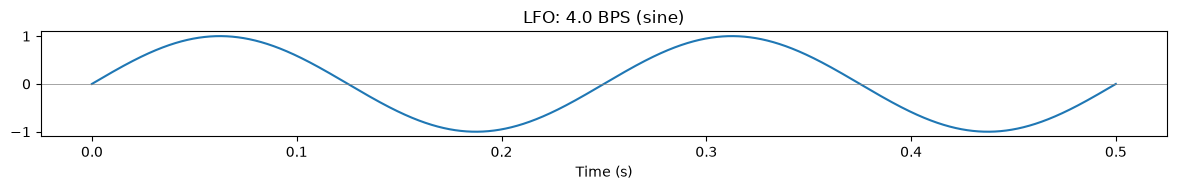

In [5]:
def make_lfo(num_samples, bps, sr, waveform='sine'):
    """Generate an LFO signal at the given BPS rate."""
    t = torch.arange(num_samples, dtype=torch.float32) / sr
    phase = 2 * math.pi * bps * t
    if waveform == 'sine':
        lfo = torch.sin(phase)
    elif waveform == 'triangle':
        lfo = 2 * (phase / (2 * math.pi) % 1) - 1
    elif waveform == 'square':
        lfo = torch.sign(torch.sin(phase))
    elif waveform == 'sawtooth':
        lfo = 2 * (phase / (2 * math.pi) % 1) - 1
    else:
        raise ValueError(f'Unknown waveform: {waveform}')
    return lfo

lfo = make_lfo(len(raw_audio), BPS, SAMPLE_RATE, MOD_WAVEFORM)
print(f'LFO: {BPS} Hz, {MOD_WAVEFORM}, {len(lfo)} samples')

# Plot LFO
fig, ax = plt.subplots(figsize=(12, 2))
t = torch.arange(len(lfo)) / SAMPLE_RATE
ax.plot(t[:int(SAMPLE_RATE * 2 / BPS)].numpy(), lfo[:int(SAMPLE_RATE * 2 / BPS)].numpy())
ax.set_title(f'LFO: {BPS} BPS ({MOD_WAVEFORM})')
ax.set_xlabel('Time (s)')
ax.axhline(0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()

## Step 4: BPS modulation — Tremolo (amplitude LFO)

Modulate the amplitude at the BPS rate. Depth controls how much the
volume dips (0 = no effect, 1 = full on/off pulsing).

In [6]:
def apply_tremolo(audio, lfo, depth, sr=24000):
    """Amplitude modulation: audio * (1 - depth * (1 - lfo) / 2).
    LFO in [-1, 1] mapped to [1-depth, 1] gain range."""
    gain = 1.0 - depth * (1.0 - lfo) / 2.0
    return audio * gain

audio_after_trem = raw_audio.clone()
if ENABLE_TREMOLO:
    audio_after_trem = apply_tremolo(audio_after_trem, lfo, TREMOLO_DEPTH, SAMPLE_RATE)
    audio_after_trem = audio_after_trem - audio_after_trem.mean()  # DC-block: decoder emits large DC (PR #59)
    peak = audio_after_trem.abs().max()
    if peak > 0:
        audio_after_trem = audio_after_trem / peak
    print(f'Tremolo applied: depth={TREMOLO_DEPTH}, BPS={BPS}')
else:
    print('Tremolo disabled')

display(Audio(audio_after_trem.numpy(), rate=SAMPLE_RATE))

Tremolo applied: depth=0.6, BPS=4.0


## Step 5: BPS modulation — Vibrato (pitch LFO)

Modulate the pitch at the BPS rate. Uses windowed variable-speed
resampling: each window's resampling ratio oscillates with the LFO.

In [7]:
def apply_vibrato(audio, lfo, depth_semitones, sr=24000, window_ms=10):
    """Pitch modulation via windowed variable-speed resampling.
    
    depth_semitones: peak pitch deviation in semitones.
    """
    if depth_semitones == 0:
        return audio
    
    window_samples = max(1, int(sr * window_ms / 1000))
    num_windows = max(1, len(audio) // window_samples)
    
    # LFO in [-1, 1] -> pitch shift in [-depth, +depth] semitones
    pitch_shifts = lfo[:num_windows] * depth_semitones
    # Semitones to ratio: +n st = speed up by 2^(n/12)
    ratios = 2.0 ** (pitch_shifts / 12.0)
    
    resampled_chunks = []
    for i in range(num_windows):
        start = i * window_samples
        end = min(start + window_samples, len(audio))
        chunk = audio[start:end]
        if len(chunk) == 0:
            break
        new_len = max(1, int(len(chunk) / ratios[i].item()))
        chunk_2d = chunk.unsqueeze(0).unsqueeze(0)
        resampled = torch.nn.functional.interpolate(
            chunk_2d, size=new_len, mode='linear', align_corners=False
        )
        resampled_chunks.append(resampled.squeeze())
    
    return torch.cat(resampled_chunks)

audio_after_vib = audio_after_trem.clone()
if ENABLE_VIBRATO:
    audio_after_vib = apply_vibrato(audio_after_vib, lfo, VIBRATO_DEPTH, SAMPLE_RATE)
    audio_after_vib = audio_after_vib - audio_after_vib.mean()  # DC-block: decoder emits large DC (PR #59)
    peak = audio_after_vib.abs().max()
    if peak > 0:
        audio_after_vib = audio_after_vib / peak
    print(f'Vibrato applied: depth={VIBRATO_DEPTH} st, BPS={BPS}')
else:
    print('Vibrato disabled')

display(Audio(audio_after_vib.numpy(), rate=SAMPLE_RATE))

Vibrato applied: depth=1.5 st, BPS=4.0


## Step 6: BPS modulation — Filter sweep (cutoff LFO)

Modulate a filter cutoff at the BPS rate using pedalboard's `PeakFilter`.
The cutoff oscillates between `FILTER_SWEEP_MIN` and `FILTER_SWEEP_MAX` Hz.

In [8]:
def apply_filter_sweep(audio, lfo, min_hz, max_hz, sr=24000, window_ms=25):
    """Modulate a peak filter cutoff at the LFO rate.
    
    Applies a new PeakFilter for each window with cutoff = lfo-mapped freq.
    """
    if min_hz <= 0 or max_hz <= 0:
        return audio
    
    window_samples = max(1, int(sr * window_ms / 1000))
    num_windows = max(1, len(audio) // window_samples)
    
    # LFO in [-1, 1] -> cutoff in [min_hz, max_hz]
    lfo_norm = (lfo[:num_windows] + 1) / 2  # [0, 1]
    cutoffs = min_hz + (max_hz - min_hz) * lfo_norm
    
    chunks = []
    for i in range(num_windows):
        start = i * window_samples
        end = min(start + window_samples, len(audio))
        chunk = audio[start:end].numpy()
        if len(chunk) == 0:
            break
        cutoff = float(cutoffs[i].item())
        board = Pedalboard([PeakFilter(cutoff_frequency_hz=cutoff, gain_db=6.0, q=2.0)])
        processed = board(chunk, sr)
        chunks.append(torch.from_numpy(processed))
    
    return torch.cat(chunks)

audio_after_sweep = audio_after_vib.clone()
if ENABLE_FILTER_SWEEP:
    audio_after_sweep = apply_filter_sweep(
        audio_after_sweep, lfo, FILTER_SWEEP_MIN, FILTER_SWEEP_MAX, SAMPLE_RATE
    )
    audio_after_sweep = audio_after_sweep - audio_after_sweep.mean()  # DC-block: decoder emits large DC (PR #59)
    peak = audio_after_sweep.abs().max()
    if peak > 0:
        audio_after_sweep = audio_after_sweep / peak
    print(f'Filter sweep: {FILTER_SWEEP_MIN}-{FILTER_SWEEP_MAX} Hz at {BPS} BPS')
else:
    print('Filter sweep disabled')

display(Audio(audio_after_sweep.numpy(), rate=SAMPLE_RATE))

Filter sweep: 400-6000 Hz at 4.0 BPS


## Step 7: Pedalboard effects chain

Apply a chain of professional audio effects via pedalboard. Toggle each
effect on/off with the `PB_*` knobs.

In [9]:
def build_pedalboard():
    """Build the pedalboard effect chain from knobs."""
    effects = []
    if PB_COMPRESSOR:
        effects.append(Compressor(
            threshold_db=PB_COMP_THRESHOLD,
            ratio=PB_COMP_RATIO,
        ))
    if PB_DISTORTION:
        effects.append(Distortion(drive_db=PB_DIST_DRIVE))
    if PB_BITCRUSH:
        effects.append(Bitcrush(bit_depth=PB_BIT_DEPTH))
    if PB_CHORUS:
        effects.append(Chorus())
    if PB_PHASER:
        effects.append(Phaser())
    if PB_DELAY:
        effects.append(Delay(
            delay_seconds=PB_DELAY_SECONDS,
            mix=PB_DELAY_MIX,
        ))
    if PB_REVERB:
        effects.append(Reverb(room_size=PB_REVERB_ROOM))
    effects.append(Limiter(threshold_db=-1.0))
    return Pedalboard(effects)

board = build_pedalboard()
print(f'Pedalboard chain: {[type(e).__name__ for e in board]}')

audio_np = audio_after_sweep.numpy().astype(np.float32)
audio_after_pb = torch.from_numpy(board(audio_np, SAMPLE_RATE))

audio_after_pb = audio_after_pb - audio_after_pb.mean()  # DC-block: decoder emits large DC (PR #59)
peak = audio_after_pb.abs().max()
if peak > 0:
    audio_after_pb = audio_after_pb / peak

print(f'After pedalboard: {audio_after_pb.shape[-1]} samples')
display(Audio(audio_after_pb.numpy(), rate=SAMPLE_RATE))

Pedalboard chain: ['Compressor', 'Delay', 'Reverb', 'Limiter']
After pedalboard: 139800 samples


## Step 8: scipy.signal custom filter

Apply a high-order IIR filter designed with scipy. Options:
- **Butterworth**: maximally flat passband
- **Chebyshev Type I**: ripple in passband, steeper rolloff
- **Chebyshev Type II**: ripple in stopband, no passband ripple
- **Elliptic**: ripple in both bands, steepest rolloff

In [10]:
def apply_scipy_filter(audio, filter_type, ftype, order, cutoff, cutoff2,
                      ripple=5.0, attenuation=40.0, sr=24000):
    """Apply a scipy.signal IIR filter.
    
    Parameters
    ----------
    filter_type : str
        'butter', 'cheby1', 'cheby2', 'ellip', or 'none'
    ftype : str
        'lowpass', 'highpass', 'bandpass'
    order : int
        Filter order
    cutoff, cutoff2 : float
        Cutoff frequency (Hz). For bandpass: [cutoff, cutoff2].
    ripple : float
        Passband ripple in dB (cheby1, ellip)
    attenuation : float
        Stopband attenuation in dB (cheby2, ellip)
    sr : int
        Sample rate
    """
    if filter_type == 'none':
        return audio
    
    nyq = sr / 2
    
    if ftype == 'bandpass':
        wn = [cutoff / nyq, cutoff2 / nyq]
    else:
        wn = cutoff / nyq
    
    # Design filter
    if filter_type == 'butter':
        sos = scisig.butter(order, wn, btype=ftype, output='sos')
    elif filter_type == 'cheby1':
        sos = scisig.cheby1(order, ripple, wn, btype=ftype, output='sos')
    elif filter_type == 'cheby2':
        sos = scisig.cheby2(order, attenuation, wn, btype=ftype, output='sos')
    elif filter_type == 'ellip':
        sos = scisig.ellip(order, ripple, attenuation, wn, btype=ftype, output='sos')
    else:
        raise ValueError(f'Unknown filter type: {filter_type}')
    
    # Apply with zero-phase filtering (filtfilt)
    filtered = scisig.sosfiltfilt(sos, audio.numpy())
    return torch.from_numpy(filtered)

audio_after_scipy = apply_scipy_filter(
    audio_after_pb, SCIPY_FILTER, SCIPY_FILTER_TYPE, SCIPY_FILTER_ORDER,
    SCIPY_FILTER_CUTOFF, SCIPY_FILTER_CUTOFF2,
    SCIPY_RIPPLE, SCIPY_ATTENUATION, SAMPLE_RATE,
)

audio_after_scipy = audio_after_scipy - audio_after_scipy.mean()  # DC-block: decoder emits large DC (PR #59)
peak = audio_after_scipy.abs().max()
if peak > 0:
    audio_after_scipy = audio_after_scipy / peak

print(f'scipy filter: {SCIPY_FILTER} {SCIPY_FILTER_TYPE} order={SCIPY_FILTER_ORDER} cutoff={SCIPY_FILTER_CUTOFF}Hz')
print(f'After scipy: {audio_after_scipy.shape[-1]} samples')
display(Audio(audio_after_scipy.numpy(), rate=SAMPLE_RATE))

scipy filter: none lowpass order=4 cutoff=6000Hz
After scipy: 139800 samples


## Step 9: Full pipeline comparison

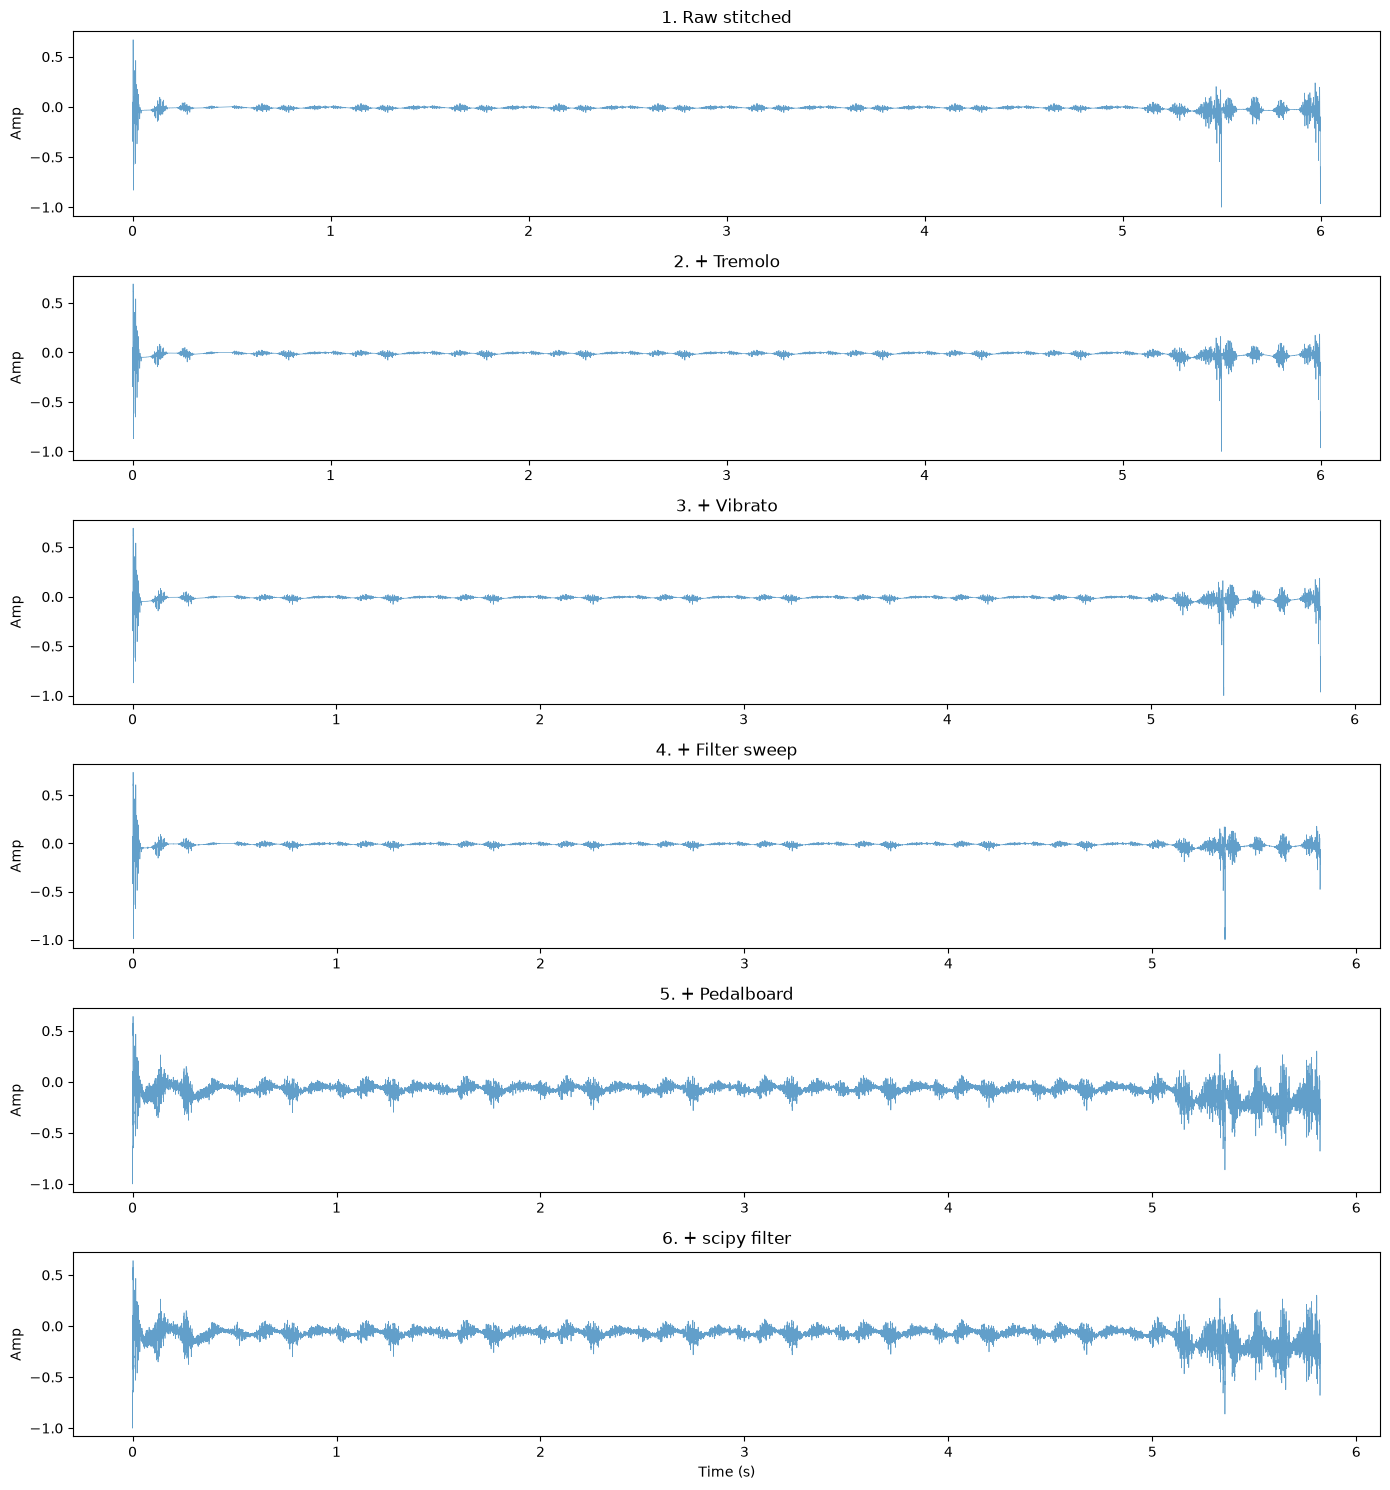

In [11]:
stages = [
    ('1. Raw stitched', raw_audio),
    ('2. + Tremolo', audio_after_trem) if ENABLE_TREMOLO else None,
    ('3. + Vibrato', audio_after_vib) if ENABLE_VIBRATO else None,
    ('4. + Filter sweep', audio_after_sweep) if ENABLE_FILTER_SWEEP else None,
    ('5. + Pedalboard', audio_after_pb),
    ('6. + scipy filter', audio_after_scipy),
]
stages = [s for s in stages if s is not None]

fig, axes = plt.subplots(len(stages), 1, figsize=(14, 2.5 * len(stages)))
if len(stages) == 1:
    axes = [axes]
for ax, (name, audio) in zip(axes, stages):
    t = torch.arange(len(audio)) / SAMPLE_RATE
    ax.plot(t.numpy(), audio.numpy(), alpha=0.7, linewidth=0.5)
    ax.set_title(name)
    ax.set_ylabel('Amp')
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

In [12]:
print('=== Final output ===')
display(Audio(audio_after_scipy.numpy(), rate=SAMPLE_RATE))
print('=== Raw (no processing) ===')
display(Audio(raw_audio.numpy(), rate=SAMPLE_RATE))

=== Final output ===


=== Raw (no processing) ===


## Step 10: Generate variations

Reuse the trained models to generate different sounds by changing
BPS rate, modulation depths, and effect settings.

In [13]:
def full_pipeline(seed, bps, trem_depth, vib_depth, sweep_min, sweep_max,
                  reverb_room, delay_sec, dist_drive, label=''):
    """Full generation + modulation + effects pipeline."""
    # Generate segments
    segs = [generate_segment(seed + i * 1000) for i in range(num_segments)]
    audio = overlap_add(segs, OVERLAP_FRAC)
    if len(audio) > TOTAL_LENGTH:
        audio = audio[:TOTAL_LENGTH]
    elif len(audio) < TOTAL_LENGTH:
        audio = torch.nn.functional.pad(audio, (0, TOTAL_LENGTH - len(audio)))
    
    # LFO
    lfo = make_lfo(len(audio), bps, SAMPLE_RATE, MOD_WAVEFORM)
    
    # Tremolo
    audio = apply_tremolo(audio, lfo, trem_depth, SAMPLE_RATE)
    # Vibrato
    audio = apply_vibrato(audio, lfo, vib_depth, SAMPLE_RATE)
    # Filter sweep
    audio = apply_filter_sweep(audio, lfo, sweep_min, sweep_max, SAMPLE_RATE)
    
    # Pedalboard
    board = Pedalboard([
        Compressor(threshold_db=-20, ratio=4),
        Distortion(drive_db=dist_drive) if dist_drive > 0 else Gain(gain_db=0),
        Delay(delay_seconds=delay_sec, mix=0.25),
        Reverb(room_size=reverb_room),
        Limiter(threshold_db=-1.0),
    ])
    audio = torch.from_numpy(board(audio.numpy().astype(np.float32), SAMPLE_RATE))
    
    audio = audio - audio.mean()  # DC-block: decoder emits large DC (PR #59)
    peak = audio.abs().max()
    if peak > 0:
        audio = audio / peak
    
    print(f'{label}: bps={bps} trem={trem_depth} vib={vib_depth}st '
          f'sweep={sweep_min}-{sweep_max}Hz reverb={reverb_room} delay={delay_sec}s')
    display(Audio(audio.numpy(), rate=SAMPLE_RATE))
    return audio

# V1: Fast tremolo, no vibrato, bright sweep
v1 = full_pipeline(seed=100, bps=8, trem_depth=0.8, vib_depth=0,
                    sweep_min=1000, sweep_max=10000, reverb_room=0.2,
                    delay_sec=0.125, dist_drive=0, label='Fast pulse, bright')

Fast pulse, bright: bps=8 trem=0.8 vib=0st sweep=1000-10000Hz reverb=0.2 delay=0.125s


In [14]:
# V2: Slow vibrato, dark, heavy reverb
v2 = full_pipeline(seed=200, bps=1.5, trem_depth=0.2, vib_depth=3,
                    sweep_min=200, sweep_max=2000, reverb_room=0.7,
                    delay_sec=0.5, dist_drive=0, label='Slow vib, dark, ambient')

Slow vib, dark, ambient: bps=1.5 trem=0.2 vib=3st sweep=200-2000Hz reverb=0.7 delay=0.5s


In [15]:
# V3: Medium BPS, distortion, tight delay
v3 = full_pipeline(seed=300, bps=4, trem_depth=0.5, vib_depth=0.5,
                    sweep_min=500, sweep_max=5000, reverb_room=0.3,
                    delay_sec=0.1875, dist_drive=15, label='Gritty, rhythmic')

Gritty, rhythmic: bps=4 trem=0.5 vib=0.5st sweep=500-5000Hz reverb=0.3 delay=0.1875s


In [16]:
# V4: Slow BPS, triangle wave, wide sweep
v4 = full_pipeline(seed=42, bps=2, trem_depth=0.4, vib_depth=2,
                    sweep_min=300, sweep_max=8000, reverb_room=0.5,
                    delay_sec=0.375, dist_drive=0, label='Wide sweep, dreamy')

Wide sweep, dreamy: bps=2 trem=0.4 vib=2st sweep=300-8000Hz reverb=0.5 delay=0.375s


## Summary

This notebook adds **BPS-synchronized modulation** and **open-source
plugin effects** to the long-form generation pipeline:

### BPS modulation knobs
| Knob | Effect | Range |
|------|--------|-------|
| `BPS` | LFO rate (beats per second) | 0.5-16 |
| `TREMOLO_DEPTH` | Amplitude modulation depth | 0-1 |
| `VIBRATO_DEPTH` | Pitch modulation depth | 0-12 semitones |
| `FILTER_SWEEP_MIN/MAX` | Filter cutoff range | 100-12000 Hz |
| `MOD_WAVEFORM` | LFO shape | sine, triangle, square, sawtooth |

### Pedalboard effect knobs
| Knob | Effect |
|------|--------|
| `PB_COMPRESSOR` | Dynamic range compression |
| `PB_REVERB` | Room reverb |
| `PB_DELAY` | Echo delay |
| `PB_CHORUS` | Modulated delay chorus |
| `PB_DISTORTION` | Waveshaper distortion |
| `PB_PHASER` | Allpass phaser |
| `PB_BITCRUSH` | Sample rate / bit depth reduction |

### scipy.signal filter knobs
| Knob | Options |
|------|---------|
| `SCIPY_FILTER` | butter, cheby1, cheby2, ellip |
| `SCIPY_FILTER_TYPE` | lowpass, highpass, bandpass |
| `SCIPY_FILTER_ORDER` | 1-8 |
| `SCIPY_FILTER_CUTOFF` | Cutoff frequency (Hz) |

### Dependencies
- [pedalboard](https://github.com/spotify/pedalboard) by Spotify
- [scipy.signal](https://docs.scipy.org/doc/scipy/reference/signal.html)
- torchaudio (for biquad filters and resampling)